# Support Vector Machine (SVM)

In [83]:
import numpy as np
import pandas as pd


# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, FunctionTransformer, OrdinalEncoder
from category_encoders import WOEEncoder
from category_encoders.cat_boost import CatBoostEncoder



from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, check_cv
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef


## Data Loading and Initial Preparation
We load the credit risk dataset and define our feature matrix `X` and target vector `y`. We also categorize our columns into numeric, nominal, and ordinal types for specific preprocessing steps.

In [72]:
df = pd.read_csv('/Users/lulin/Development/machine-learning/my-first-ml-project/data/raw/credit_risk_dataset.csv')

# Features / target
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

# Column splits
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
]
categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file",
]

ordinal_cols = [
    "loan_grade",  # Ordinal: Grades have an inherent order (e.g., A > B > C)
    "cb_person_default_on_file",  
]
nominal_cols = [
    "person_home_ownership",  # Nominal: No inherent order
    "loan_intent",            # Nominal: No inherent order
]

X.shape, y.shape

((32581, 11), (32581,))

## Dataset Splitting
To evaluate the model's performance on unseen data, we split the dataset into training (80%) and testing (20%) sets using stratified sampling to maintain class balance.

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((26064, 11), (6517, 11), (26064,), (6517,))

## Preprocessing Pipelines and Model Pipeline
We create specialized pipelines for different feature types:
* **Numeric**: Median imputation and standard scaling.
* **Categorical/Nominal**: Frequent imputation and One-Hot Encoding.
* **Ordinal**: Weight of Evidence (WOE) encoding.

Finally, we bundle these into a `ColumnTransformer` and a full `SVC` (Support Vector Classifier) pipeline.

In [74]:
# ============ NUMERIC PIPELINE ============
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    #("skew", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler()),
])

# ============ CATEGORICAL PIPELINE ============
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])
# ============ NOMINAL & ORDINAL PIPELINES ============
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("woe", WOEEncoder()),
    #("cb", CatBoostEncoder()),
])

# ============ COMBINE PIPELINES ============
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("nominal", nominal_pipeline, nominal_cols),
    ("ordinal", ordinal_pipeline, ordinal_cols),
])

# ============ FULL PIPELINE WITH MODEL ============
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(class_weight="balanced", probability=True, random_state=42)),
])

# Hyperparameter Tuning with RandomizedSearchCV
This section performs hyperparameter tuning for the SVM model using `RandomizedSearchCV`. The parameter distributions include `C`, `gamma`, and `kernel`. The search is conducted over 20 iterations with a 5-fold stratified cross-validation, optimizing for the Matthews Correlation Coefficient (MCC).

In [75]:
# ============ HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV ============
# Define parameter distributions for SVM hyperparameters
C_values = [0.1, 1, 10, 50]
gamma_values = [0.0001, 0.0005, 0.001, 0.005]
kernel_values = ['linear', 'rbf', 'poly']

param_distributions = {
    "model__C": C_values,
    "model__gamma": gamma_values,
    "model__kernel": kernel_values,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    param_distributions=param_distributions,
    estimator=pipeline,
    cv=skf,
    scoring="matthews_corrcoef",
    n_jobs=-1,
    verbose=0,
    n_iter=20,  # Number of parameter settings sampled
    random_state=42
)

random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.1, 1, ...], 'model__gamma': [0.0001, 0.0005, ...], 'model__kernel': ['linear', 'rbf', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'matthews_corrcoef'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchan

In [76]:
# Fit on TRAINING data only
random_search.fit(X_train, y_train)

python(35320) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(35321) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(35322) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(35323) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(35324) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(35325) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(35326) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(35327) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.1, 1, ...], 'model__gamma': [0.0001, 0.0005, ...], 'model__kernel': ['linear', 'rbf', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'matthews_corrcoef'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchan

In [77]:
random_search.cv_results_

{'mean_fit_time': array([  779.44169827,   387.13891506,   486.06331997,   360.53140492,
          708.49933209,   362.85061417,   325.99703093,   371.30976558,
          470.39243765,   365.32469978,   450.72982225,   275.91068902,
          274.00287175,  2298.89038782,   669.78689356,  1137.66349163,
         6729.82542725, 12313.52795396,  1918.66789274,  2256.34818602]),
 'std_fit_time': array([1.14394220e+01, 6.83973943e+00, 1.85213909e+00, 5.39216041e+00,
        1.13192258e+01, 2.58679215e+00, 1.89988885e+00, 6.22749294e+00,
        1.77649624e+00, 3.88024372e+00, 2.93768044e+00, 2.21840480e+00,
        1.73046991e+00, 7.35582726e+02, 8.59417539e+00, 1.43142231e+03,
        3.46984176e+02, 2.50366620e+03, 6.10127794e+02, 1.18248889e+03]),
 'mean_score_time': array([  5.08152547,  19.09973474,  11.15833797,  16.34847012,
          4.78965468,  17.20147023,   4.62453895,  17.68169465,
         24.98291759,  18.26868463,  10.1765305 ,   4.57444119,
          4.51435685,   4.303960

In [78]:
random_search.best_score_

0.5855031185354833

In [79]:
random_search.best_params_

{'model__kernel': 'rbf', 'model__gamma': 0.001, 'model__C': 50}

In [80]:
random_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

## Model Evaluation and Visualization
After fitting the model, we evaluate its performance using a detailed classification report, confusion matrices (counts and normalized), and ROC/Precision-Recall curves.

In [84]:
# Evaluate on TEST set
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate all metrics
final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred, average='weighted')
final_recall = recall_score(y_test, y_pred, average='weighted')
final_f1 = f1_score(y_test, y_pred, average='weighted')
final_mcc = matthews_corrcoef(y_test, y_pred)
final_roc_auc = roc_auc_score(y_test, y_prob)

print("="*70)
print("FINAL TEST SET PERFORMANCE")
print("="*70)
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-Score:  {final_f1:.4f}")
print(f"Matthews Correlation Coefficient: {final_mcc:.4f}")
print(f"ROC-AUC:   {final_roc_auc:.4f}")

FINAL TEST SET PERFORMANCE
Accuracy:  0.8395
Precision: 0.8582
Recall:    0.8395
F1-Score:  0.8458
Matthews Correlation Coefficient: 0.5774
ROC-AUC:   0.8871


### Model Evaluation and Visualization
This cell evaluates the trained model on the test set. It generates a confusion matrix, ROC curve, and precision-recall curve, and displays a detailed classification report to summarize the model's performance.

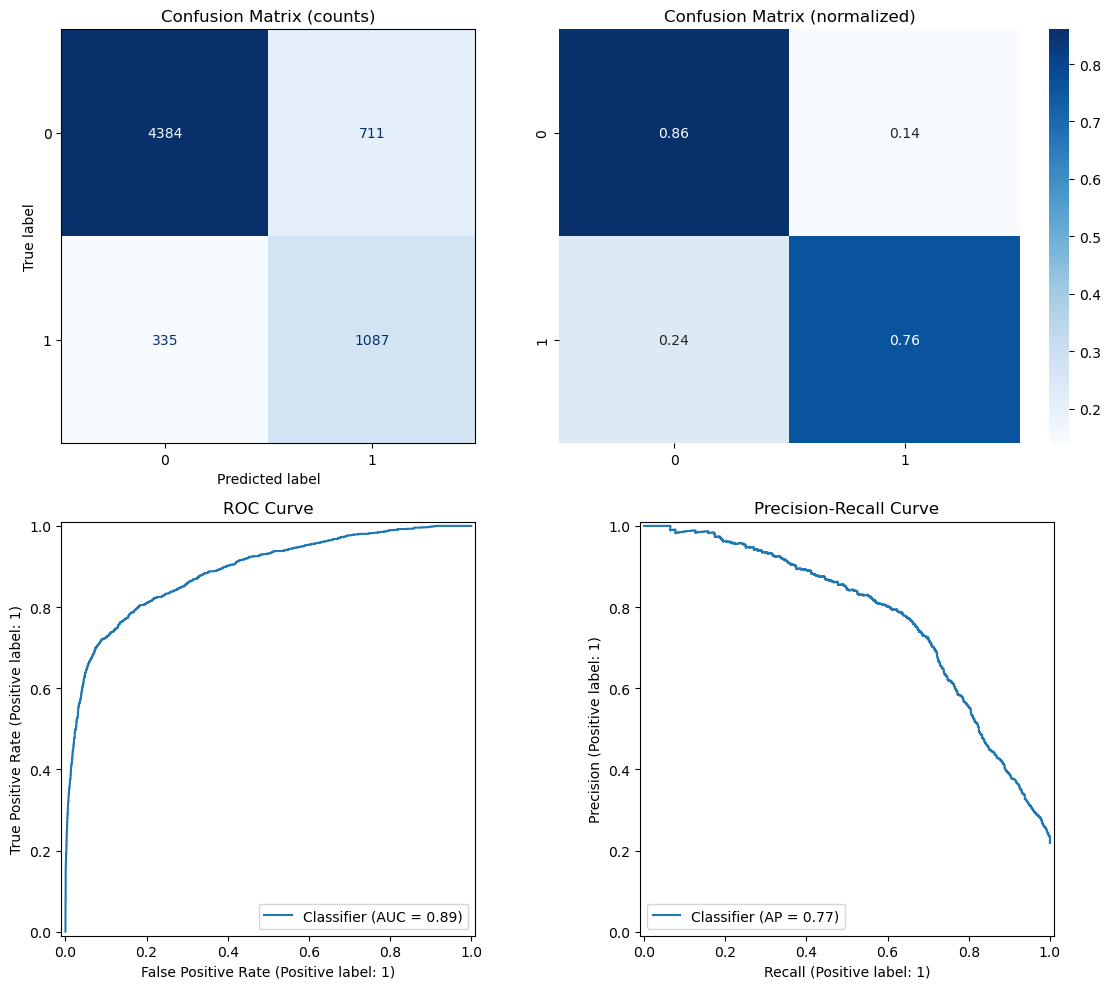


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

Approved (0)       0.93      0.86      0.89      5095
  Denied (1)       0.60      0.76      0.68      1422

    accuracy                           0.84      6517
   macro avg       0.77      0.81      0.78      6517
weighted avg       0.86      0.84      0.85      6517



In [82]:
# Confusion Matrix and additional visualizations
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Confusion matrix (counts)
ConfusionMatrixDisplay(cm).plot(ax=axes[0, 0], cmap="Blues", colorbar=False)
axes[0, 0].set_title("Confusion Matrix (counts)")

# Confusion matrix (normalized)
cmn = confusion_matrix(y_test, y_pred, normalize="true")
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", ax=axes[0, 1])
axes[0, 1].set_title("Confusion Matrix (normalized)")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1, 0])
axes[1, 0].set_title("ROC Curve")

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1, 1])
axes[1, 1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred, target_names=["Approved (0)", "Denied (1)"]))